# Can we build a balanced meal from the McDonald's menu?

This project explores whether it is possible to construct a nutritionally balanced meal using items from the McDonald's menu.

The analysis explores calorie distribution, protein content and identifies menu items that could serve as candidates for a balanced meal.

# Research Question
Is it possible to construct a nutritionally balanced meal from items available on the McDonald´s menu?

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset
The dataset contains nutritional information for items from the McDonald's menu.

In [29]:
df = pd.read_csv("data/menu.csv")

## Data Overview

In [30]:
df.head()

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


In [31]:
df.tail()

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
255,Smoothies & Shakes,McFlurry with Oreo Cookies (Small),10.1 oz (285 g),510,150,17.0,26,9.0,44,0.5,...,80,27,1,4,64,12,15,0,40,8
256,Smoothies & Shakes,McFlurry with Oreo Cookies (Medium),13.4 oz (381 g),690,200,23.0,35,12.0,58,1.0,...,106,35,1,5,85,15,20,0,50,10
257,Smoothies & Shakes,McFlurry with Oreo Cookies (Snack),6.7 oz (190 g),340,100,11.0,17,6.0,29,0.0,...,53,18,1,2,43,8,10,0,25,6
258,Smoothies & Shakes,McFlurry with Reese's Peanut Butter Cups (Medium),14.2 oz (403 g),810,290,32.0,50,15.0,76,1.0,...,114,38,2,9,103,21,20,0,60,6
259,Smoothies & Shakes,McFlurry with Reese's Peanut Butter Cups (Snack),7.1 oz (202 g),410,150,16.0,25,8.0,38,0.0,...,57,19,1,5,51,10,10,0,30,4


In [32]:
df.shape

(260, 24)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null    str    
 1   Item                           260 non-null    str    
 2   Serving Size                   260 non-null    str    
 3   Calories                       260 non-null    int64  
 4   Calories from Fat              260 non-null    int64  
 5   Total Fat                      260 non-null    float64
 6   Total Fat (% Daily Value)      260 non-null    int64  
 7   Saturated Fat                  260 non-null    float64
 8   Saturated Fat (% Daily Value)  260 non-null    int64  
 9   Trans Fat                      260 non-null    float64
 10  Cholesterol                    260 non-null    int64  
 11  Cholesterol (% Daily Value)    260 non-null    int64  
 12  Sodium                         260 non-null    int64  
 13  S

In [34]:
df.describe()

,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),Sodium,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,368.269231,127.096154,14.165385,21.815385,6.007692,29.965385,0.203846,54.942308,18.392308,495.750000,...,47.346154,15.780769,1.630769,6.530769,29.423077,13.338462,13.426923,8.534615,20.973077,7.734615
std,240.269886,127.875914,14.205998,21.885199,5.321873,26.639209,0.429133,87.269257,29.091653,577.026323,...,28.252232,9.419544,1.567717,6.307057,28.679797,11.426146,24.366381,26.345542,17.019953,8.723263
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,210.000000,20.000000,2.375000,3.750000,1.000000,4.750000,0.000000,5.000000,2.000000,107.500000,...,30.000000,10.000000,0.000000,0.000000,5.750000,4.000000,2.000000,0.000000,6.000000,0.000000
50%,340.000000,100.000000,11.000000,17.000000,5.000000,24.000000,0.000000,35.000000,11.000000,190.000000,...,44.000000,15.000000,1.000000,5.000000,17.500000,12.000000,8.000000,0.000000,20.000000,4.000000
75%,500.000000,200.000000,22.250000,35.000000,10.000000,48.000000,0.000000,65.000000,21.250000,865.000000,...,60.000000,20.000000,3.000000,10.000000,48.000000,19.000000,15.000000,4.000000,30.000000,15.000000
max,1880.000000,1060.000000,118.000000,182.000000,20.000000,102.000000,2.500000,575.000000,192.000000,3600.000000,...,141.000000,47.000000,7.000000,28.000000,128.000000,87.000000,170.000000,240.000000,70.000000,40.000000


In [35]:
df.columns

Index(['Category', 'Item', 'Serving Size', 'Calories', 'Calories from Fat',
       'Total Fat', 'Total Fat (% Daily Value)', 'Saturated Fat',
       'Saturated Fat (% Daily Value)', 'Trans Fat', 'Cholesterol',
       'Cholesterol (% Daily Value)', 'Sodium', 'Sodium (% Daily Value)',
       'Carbohydrates', 'Carbohydrates (% Daily Value)', 'Dietary Fiber',
       'Dietary Fiber (% Daily Value)', 'Sugars', 'Protein',
       'Vitamin A (% Daily Value)', 'Vitamin C (% Daily Value)',
       'Calcium (% Daily Value)', 'Iron (% Daily Value)'],
      dtype='str')

## Exploratory Data Analysis

In [36]:
df["Category"].value_counts()

Category
Coffee & Tea          95
Breakfast             42
Smoothies & Shakes    28
Chicken & Fish        27
Beverages             27
Beef & Pork           15
Snacks & Sides        13
Desserts               7
Salads                 6
Name: count, dtype: int64

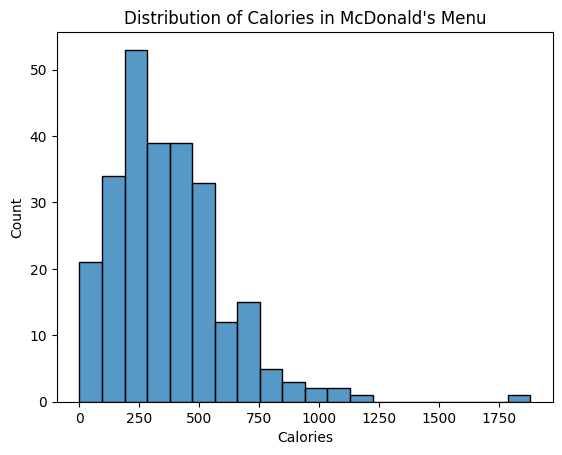

In [37]:
sns.histplot (df["Calories"], bins=20)
plt.title("Distribution of Calories in McDonald's Menu")
plt.xlabel("Calories")
plt.ylabel("Count")
plt.show()

In [38]:
df.groupby("Category")["Calories"].mean()

Category
Beef & Pork           494.000000
Beverages             113.703704
Breakfast             526.666667
Chicken & Fish        552.962963
Coffee & Tea          283.894737
Desserts              222.142857
Salads                270.000000
Smoothies & Shakes    531.428571
Snacks & Sides        245.769231
Name: Calories, dtype: float64

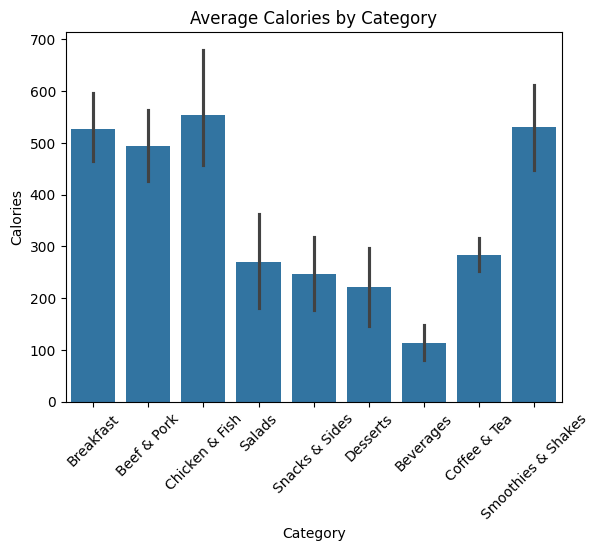

In [39]:
sns.barplot(x="Category", y="Calories", data=df)
plt.xticks(rotation=45)
plt.title("Average Calories by Category")
plt.show()

In [40]:
df.sort_values("Calories",ascending=False).head(30)

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
82,Chicken & Fish,Chicken McNuggets (40 piece),22.8 oz (646 g),1880,1060,118.0,182,20.0,101,1.0,...,118,39,6,24,1,87,0,15,8,25
32,Breakfast,Big Breakfast with Hotcakes (Large Biscuit),15.3 oz (434 g),1150,540,60.0,93,20.0,100,0.0,...,116,39,7,28,17,36,15,2,30,40
31,Breakfast,Big Breakfast with Hotcakes (Regular Biscuit),14.8 oz (420 g),1090,510,56.0,87,19.0,96,0.0,...,111,37,6,23,17,36,15,2,25,40
34,Breakfast,Big Breakfast with Hotcakes and Egg Whites (La...,15.4 oz (437 g),1050,450,50.0,77,16.0,81,0.0,...,115,38,7,28,18,35,4,2,25,30
33,Breakfast,Big Breakfast with Hotcakes and Egg Whites (Re...,14.9 oz (423 g),990,410,46.0,70,16.0,78,0.0,...,110,37,6,23,17,35,0,2,25,30
81,Chicken & Fish,Chicken McNuggets (20 piece),11.4 oz (323 g),940,530,59.0,91,10.0,50,0.0,...,59,20,3,12,0,44,0,8,4,10
253,Smoothies & Shakes,McFlurry with M&M’s Candies (Medium),16.2 oz (460 g),930,290,33.0,50,20.0,102,1.0,...,139,46,2,7,128,20,25,0,70,10
249,Smoothies & Shakes,Chocolate Shake (Large),22 fl oz cup,850,210,23.0,36,15.0,74,1.0,...,141,47,2,8,120,19,30,0,60,15
246,Smoothies & Shakes,Strawberry Shake (Large),22 fl oz cup,850,210,24.0,36,15.0,75,1.0,...,140,47,0,0,123,18,30,0,70,0
251,Smoothies & Shakes,Shamrock Shake (Large),22 fl oz cup,820,210,23.0,35,15.0,73,1.0,...,135,45,0,0,115,18,30,0,60,0


In [41]:
df.sort_values("Calories").head(30)

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
140,Coffee & Tea,Iced Tea (Child),12 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
139,Coffee & Tea,Iced Tea (Large),30 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
136,Beverages,Dasani Water Bottle,16.9 fl oz,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
115,Beverages,Diet Coke (Medium),21 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
122,Beverages,Diet Dr Pepper (Small),16 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,0,2,0,0,0,0
116,Beverages,Diet Coke (Large),30 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
114,Beverages,Diet Coke (Small),16 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
117,Beverages,Diet Coke (Child),12 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
138,Coffee & Tea,Iced Tea (Medium),21 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
123,Beverages,Diet Dr Pepper (Medium),21 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,0,3,0,0,0,0


In [42]:
df.sort_values("Protein", ascending=False).head(10)

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
82,Chicken & Fish,Chicken McNuggets (40 piece),22.8 oz (646 g),1880,1060,118.0,182,20.0,101,1.0,...,118,39,6,24,1,87,0,15,8,25
47,Beef & Pork,Double Quarter Pounder with Cheese,10 oz (283 g),750,380,43.0,66,19.0,96,2.5,...,42,14,3,11,10,48,10,2,30,35
81,Chicken & Fish,Chicken McNuggets (20 piece),11.4 oz (323 g),940,530,59.0,91,10.0,50,0.0,...,59,20,3,12,0,44,0,8,4,10
60,Chicken & Fish,Premium Grilled Chicken Club Sandwich,8.3 oz (235 g),510,180,20.0,31,7.0,36,0.0,...,44,15,3,13,9,40,8,20,30,20
64,Chicken & Fish,Bacon Clubhouse Grilled Chicken Sandwich,9.5 oz (270 g),590,230,25.0,39,8.0,42,0.0,...,51,17,4,15,14,40,8,30,30,15
51,Beef & Pork,Bacon Clubhouse Burger,9.5 oz (270 g),720,360,40.0,62,15.0,75,1.5,...,51,17,4,14,14,39,8,25,30,25
45,Beef & Pork,Quarter Pounder with Bacon Habanero Ranch,8.3 oz (235 g),610,280,31.0,48,13.0,64,1.5,...,46,15,3,14,10,37,8,20,25,30
44,Beef & Pork,Quarter Pounder with Bacon & Cheese,8 oz (227 g),600,260,29.0,45,13.0,63,1.5,...,48,16,3,12,12,37,6,15,25,30
71,Chicken & Fish,Premium McWrap Chicken & Bacon (Grilled Chicken),10.7 oz (302 g),480,170,19.0,28,7.0,36,0.0,...,42,14,3,13,6,36,60,25,20,20
59,Chicken & Fish,Premium Crispy Chicken Club Sandwich,8.8 oz (249 g),670,300,33.0,51,9.0,44,0.0,...,58,19,3,14,11,36,8,20,30,20


In [43]:
df["protein_ratio"] = df["Protein"] / df["Calories"]
df.sort_values("protein_ratio", ascending=False).head(20)

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value),protein_ratio
122,Beverages,Diet Dr Pepper (Small),16 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,2,0,0,0,0,inf
123,Beverages,Diet Dr Pepper (Medium),21 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,3,0,0,0,0,inf
125,Beverages,Diet Dr Pepper (Child),12 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,1,0,0,0,0,inf
124,Beverages,Diet Dr Pepper (Large),30 fl oz cup,0,0,0.0,0,0.0,0,0.0,...,0,0,0,0,4,0,0,0,0,inf
86,Salads,Premium Bacon Ranch Salad with Grilled Chicken,8.5 oz (241 g),220,80,8.0,13,4.0,20,0.0,...,3,2,10,4,29,110,30,15,8,0.131818
163,Coffee & Tea,Nonfat Latte (Small),12 fl oz cup,100,0,0.0,0,0.0,0,0.0,...,5,1,3,13,10,10,0,30,0,0.100000
165,Coffee & Tea,Nonfat Latte (Large),20 fl oz cup,170,0,0.5,1,0.0,0,0.0,...,8,1,6,21,16,15,0,50,2,0.094118
89,Salads,Premium Southwest Salad with Grilled Chicken,11.8 oz (335 g),290,80,8.0,13,2.5,13,0.0,...,9,7,28,10,27,170,30,15,15,0.093103
164,Coffee & Tea,Nonfat Latte (Medium),16 fl oz cup,130,0,0.0,0,0.0,0,0.0,...,6,1,4,16,12,15,0,40,0,0.092308
58,Chicken & Fish,Premium Grilled Chicken Classic Sandwich,7 oz (200 g),350,80,9.0,13,2.0,9,0.0,...,14,3,13,8,28,4,8,15,20,0.080000


In [44]:
df.sort_values("Carbohydrates", ascending=False).head(30)

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value),protein_ratio
249,Smoothies & Shakes,Chocolate Shake (Large),22 fl oz cup,850,210,23.0,36,15.0,74,1.0,...,47,2,8,120,19,30,0,60,15,0.022353
246,Smoothies & Shakes,Strawberry Shake (Large),22 fl oz cup,850,210,24.0,36,15.0,75,1.0,...,47,0,0,123,18,30,0,70,0,0.021176
253,Smoothies & Shakes,McFlurry with M&M’s Candies (Medium),16.2 oz (460 g),930,290,33.0,50,20.0,102,1.0,...,46,2,7,128,20,25,0,70,10,0.021505
251,Smoothies & Shakes,Shamrock Shake (Large),22 fl oz cup,820,210,23.0,35,15.0,73,1.0,...,45,0,0,115,18,30,0,60,0,0.021951
243,Smoothies & Shakes,Vanilla Shake (Large),22 fl oz cup,820,210,23.0,35,15.0,73,1.0,...,45,0,0,101,18,30,0,60,0,0.021951
82,Chicken & Fish,Chicken McNuggets (40 piece),22.8 oz (646 g),1880,1060,118.0,182,20.0,101,1.0,...,39,6,24,1,87,0,15,8,25,0.046277
32,Breakfast,Big Breakfast with Hotcakes (Large Biscuit),15.3 oz (434 g),1150,540,60.0,93,20.0,100,0.0,...,39,7,28,17,36,15,2,30,40,0.031304
34,Breakfast,Big Breakfast with Hotcakes and Egg Whites (La...,15.4 oz (437 g),1050,450,50.0,77,16.0,81,0.0,...,38,7,28,18,35,4,2,25,30,0.033333
258,Smoothies & Shakes,McFlurry with Reese's Peanut Butter Cups (Medium),14.2 oz (403 g),810,290,32.0,50,15.0,76,1.0,...,38,2,9,103,21,20,0,60,6,0.025926
248,Smoothies & Shakes,Chocolate Shake (Medium),16 fl oz cup,700,180,20.0,30,12.0,62,1.0,...,38,2,6,97,15,25,0,50,10,0.021429


## Balanced Meal Filtering

In [45]:
df[(df["Calories"]<500)&(df["Protein"]>20)]

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value),protein_ratio
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,10,4,17,2,21,15,0,30,15,0.046667
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,10,4,17,2,21,6,0,25,10,0.052500
5,Breakfast,Steak & Egg McMuffin,6.5 oz (185 g),430,210,23.0,36,9.0,46,1.0,...,10,4,18,3,26,15,2,30,20,0.060465
50,Beef & Pork,Double Cheeseburger,5.7 oz (161 g),430,190,21.0,32,10.0,52,1.0,...,12,2,8,7,24,10,2,30,20,0.055814
52,Beef & Pork,McDouble,5.2 oz (147 g),380,150,17.0,26,8.0,40,1.0,...,11,2,7,7,22,6,2,20,20,0.057895
53,Beef & Pork,Bacon McDouble,5.7 oz (161 g),440,200,22.0,34,10.0,49,1.0,...,12,2,7,7,27,6,10,20,20,0.061364
54,Beef & Pork,Daily Double,6.7 oz (190 g),430,200,22.0,35,9.0,44,1.0,...,11,2,8,7,22,8,8,20,20,0.051163
55,Beef & Pork,Jalapeño Double,5.6 oz (159 g),430,210,23.0,36,9.0,44,1.0,...,12,2,7,6,22,6,8,20,20,0.051163
58,Chicken & Fish,Premium Grilled Chicken Classic Sandwich,7 oz (200 g),350,80,9.0,13,2.0,9,0.0,...,14,3,13,8,28,4,8,15,20,0.080000
62,Chicken & Fish,Premium Grilled Chicken Ranch BLT Sandwich,7.6 oz (217 g),450,130,15.0,23,4.5,22,0.0,...,14,3,13,9,36,4,20,15,20,0.080000


## Balanced meal criteria
For the purposes of this analysis, a balanced meal candidate is defined as an item that meets following criteria: 
- 400-700 calories
- at least 25g of protein
- moderate fat (less than 25g)
- limited sugar (less than 15g)

In [46]:
# Balanced meal criteria:400-700 kcal, at least 25g protein, moderate fat, reasonable sugar
balanced_items = df[(df["Calories"] >= 400)
                    & (df["Calories"] <= 700) 
                    & (df["Protein"] >= 25)
                    & (df["Total Fat"] <= 25)
                    & (df["Sugars"] <= 15)
                    ]
balanced_items [["Category", "Item", "Calories", "Protein", "Total Fat", "Sugars"]]

,Category,Item,Calories,Protein,Total Fat,Sugars
5,Breakfast,Steak & Egg McMuffin,430,26,23.0,3
25,Breakfast,"Bacon, Egg & Cheese Bagel with Egg Whites",570,30,25.0,8
53,Beef & Pork,Bacon McDouble,440,27,22.0,7
60,Chicken & Fish,Premium Grilled Chicken Club Sandwich,510,40,20.0,9
62,Chicken & Fish,Premium Grilled Chicken Ranch BLT Sandwich,450,36,15.0,9
64,Chicken & Fish,Bacon Clubhouse Grilled Chicken Sandwich,590,40,25.0,14
71,Chicken & Fish,Premium McWrap Chicken & Bacon (Grilled Chicken),480,36,19.0,6
73,Chicken & Fish,Premium McWrap Chicken & Ranch (Grilled Chicken),450,30,18.0,6
75,Chicken & Fish,Premium McWrap Southwest Chicken (Grilled Chic...,520,31,20.0,10


In [47]:
len(balanced_items)

9

In [48]:
balanced_items["Category"].value_counts()

Category
Chicken & Fish    6
Breakfast         2
Beef & Pork       1
Name: count, dtype: int64

### Balanced meal candidates
Using the defined nutritional criteria (400 - 700 kcal and at least 25g protein), only 9 items from the McDonald´s menu qualify as potential balanced meal components.
Most of these items come from Chicken & Fish category, While very few are found in Beef & Pork or Breakfast categories.
This suggests that leaner protein options dominate the balanced candidates.

In [49]:
# lowest calories balanced items
balanced_items = df[(df["Calories"] < 500) & (df["Protein"] > 25)]
balanced_items = balanced_items.sort_values("Calories")
balanced_items[["Category", "Item", "Calories", "Protein", "Total Fat", "Sugars" ]]

,Category,Item,Calories,Protein,Total Fat,Sugars
86,Salads,Premium Bacon Ranch Salad with Grilled Chicken,220,29,8.0,4
89,Salads,Premium Southwest Salad with Grilled Chicken,290,27,8.0,10
58,Chicken & Fish,Premium Grilled Chicken Classic Sandwich,350,28,9.0,8
77,Chicken & Fish,Premium McWrap Chicken Sweet Chili (Grilled Ch...,380,27,10.0,12
5,Breakfast,Steak & Egg McMuffin,430,26,23.0,3
53,Beef & Pork,Bacon McDouble,440,27,22.0,7
73,Chicken & Fish,Premium McWrap Chicken & Ranch (Grilled Chicken),450,30,18.0,6
62,Chicken & Fish,Premium Grilled Chicken Ranch BLT Sandwich,450,36,15.0,9
71,Chicken & Fish,Premium McWrap Chicken & Bacon (Grilled Chicken),480,36,19.0,6


In [50]:
#highest protein balanced items
balanced_items = df[(df["Calories"] < 500) & (df["Protein"] > 25)]
balanced_items = balanced_items.sort_values("Protein", ascending=False)
balanced_items[["Category", "Item", "Calories", "Protein", "Total Fat", "Sugars" ]]

,Category,Item,Calories,Protein,Total Fat,Sugars
71,Chicken & Fish,Premium McWrap Chicken & Bacon (Grilled Chicken),480,36,19.0,6
62,Chicken & Fish,Premium Grilled Chicken Ranch BLT Sandwich,450,36,15.0,9
73,Chicken & Fish,Premium McWrap Chicken & Ranch (Grilled Chicken),450,30,18.0,6
86,Salads,Premium Bacon Ranch Salad with Grilled Chicken,220,29,8.0,4
58,Chicken & Fish,Premium Grilled Chicken Classic Sandwich,350,28,9.0,8
77,Chicken & Fish,Premium McWrap Chicken Sweet Chili (Grilled Ch...,380,27,10.0,12
53,Beef & Pork,Bacon McDouble,440,27,22.0,7
89,Salads,Premium Southwest Salad with Grilled Chicken,290,27,8.0,10
5,Breakfast,Steak & Egg McMuffin,430,26,23.0,3


## Conclusion
The analysis suggests that constructing a nutritionally balancedmeal from the McDonald's menu is challenging but not impossible.
Most menu items are relatively high in calories, saturated fat, or sodium while providing limited protein relative to their calorie content. As a result, only a small number of items come close to meeting the defined balanced meal criteria.
This highlights a broader pattern in fast food menus: meals are typically optimized for taste and energy desity rather than nutritional balance.
However, the analysis also shows that with carful selection, it is possible to assemble a meal that better aligns with basic nutritional guidelines.
Future analysis could explore optimal combinations of menu items or compare McDonald's nutrition profile with other fast-food chains.

## Limitations
This analysis is limited to the nutritional information available in the dataset and does not consider portion customization, regional menu variations, or micronutrient balance.